# Logistic Regression from Scratch (NumPy Implementation)

In this notebook, we implement Logistic Regression from scratch using stochastic gradient descent.

We use the sigmoid activation function and optimize the model using cross-entropy loss.

The goal is binary classification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rice_ml import train_test_split, StandardScaler

sns.set_theme()

## Dataset: Banknote Authentication

We use a real-world dataset containing statistical features extracted from images of banknotes.

The task is to classify whether a banknote is genuine or forged.

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

columns = ["variance", "skewness", "curtosis", "entropy", "class"]

df = pd.read_csv(url, header=None, names=columns)

df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## Exploratory Data Analysis

We inspect class distribution and feature structure to understand separability.

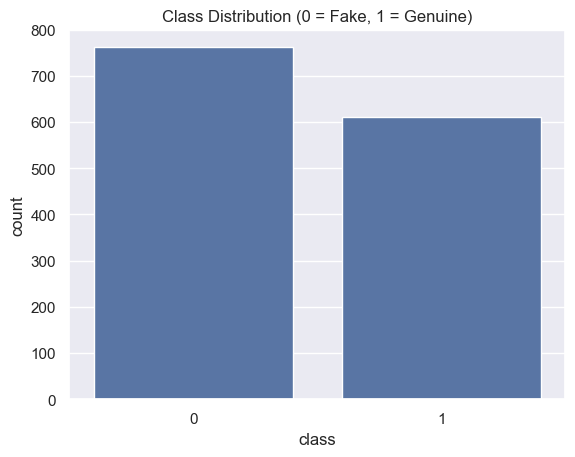

In [3]:
sns.countplot(x=df["class"])
plt.title("Class Distribution (0 = Fake, 1 = Genuine)")
plt.show()

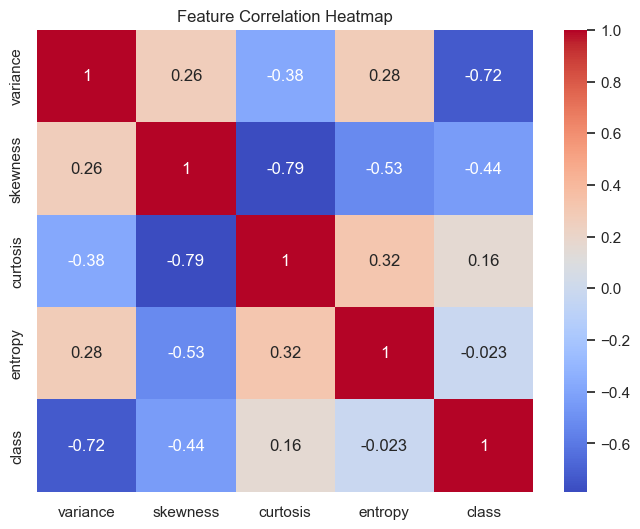

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Preprocessing

We:
- Split features and labels
- Standardize features for stable gradient descent
- Train/test split

In [5]:
X = df.drop("class", axis=1).values
y = df["class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Training Logistic Regression

We train the model using stochastic gradient descent and cross-entropy loss.

In [9]:
from rice_ml import LogisticRegression

model = LogisticRegression(eta=0.01, epochs=100)
model.train(X_train, y_train)

## Training Loss

We visualize how the cross-entropy loss decreases over epochs.

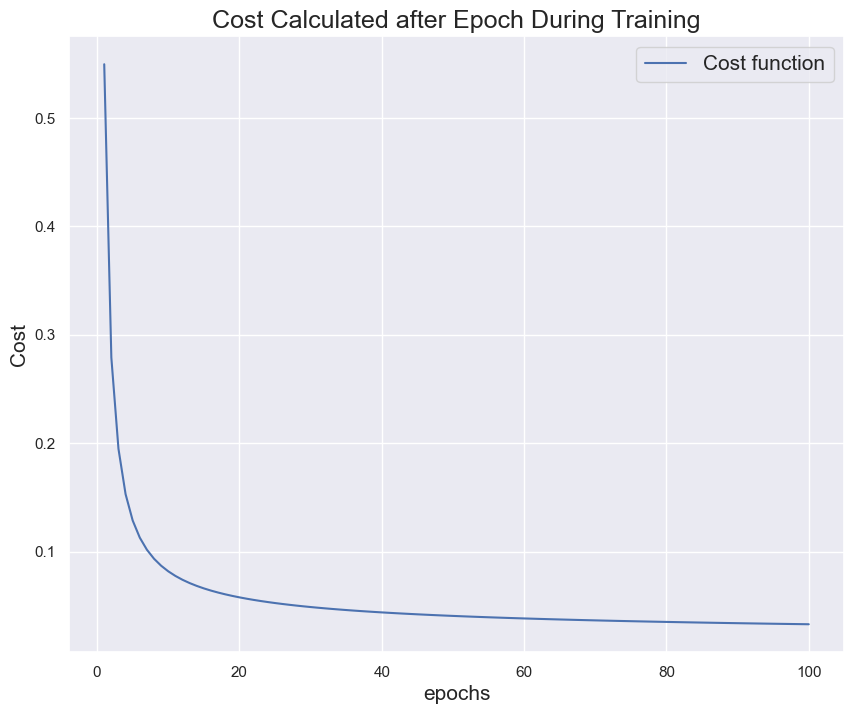

In [10]:
model.plot_cost_function()

## Evaluation

We evaluate model performance using accuracy.

In [11]:
y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 97.09%


## Decision Boundary

We visualize how the model separates the two classes using 2D feature slices.

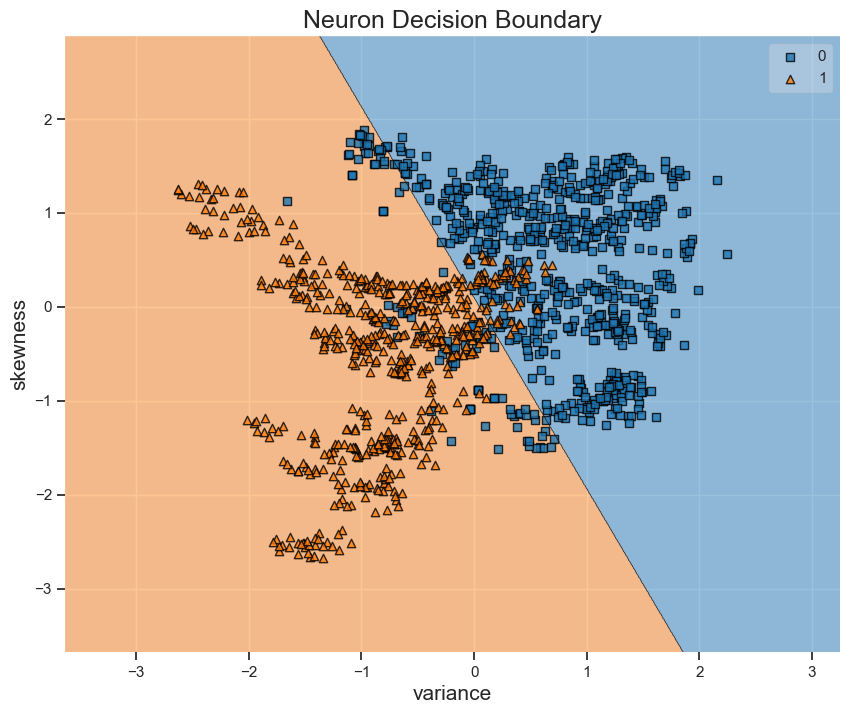

In [13]:
# Use only first two features for visualization
X_vis = X_scaled[:, [0, 1]]

model_vis = LogisticRegression(eta=0.01, epochs=100)
model_vis.train(X_vis, y)

model_vis.plot_decision_boundary(X_vis, y, "variance", "skewness")

## Final Analysis

### Key Observations:
- The model converges smoothly using stochastic gradient descent
- Cross-entropy loss decreases consistently over epochs
- Decision boundary is approximately linear, matching dataset structure
- High accuracy indicates strong linear separability

### Conclusion:
Logistic Regression is highly effective for this dataset due to its clear class separation and linear structure.